# 🔬 analysis addressing reviewer comments 4-6 (10m Grid)  ## ✅ existing codeand 100% 호환  ### 📋 analysis items요  **Comment #4:** SMOTE Robustness & Computational Efficiency - ✅ SMOTE 3가지 시나리오 comparison - ✅ 강records성 검증 (CV stability) - ✅ computational efficiency analysis  **Comment #5:** CV Standard Deviations & Overfitting - ✅ 10-fold CV with detailed std - ✅ Train vs CV vs Test comparison - ✅ Overfitting mitigation 검증 - ✅ Table 4 업데 트  **Comment #6:** SHAP Interaction Values - ✅ SHAP interaction matrix - ✅ Top feature interactions - ✅ Multicollinearity patterns  ---

In [2]:
!pip install catboost shap imbalanced-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 27.8 MB/s eta 0:00:00


In [3]:
from google.colab import drive drive.mount('/content/drive')

Mounted at /content/drive


## 1️⃣ 환경 settings

In [4]:
  from imblearn.over_sampling import SMOTE from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate from sklearn.metrics import roc_auc_score, f1_score, make_scorer from sklearn.ensemble import RandomForestClassifier from sklearn.preprocessing import StandardScaler from xgboost import XGBClassifier from catboost import CatBoostClassifier from sklearn.tree import DecisionTreeClassifier import numpy as np import pandas as pd import matplotlib.pyplot as plt import seaborn as sns import shap import time import os import warnings  warnings.filterwarnings('ignore')  # Korean font settings plt.rcParams['font.family'] = 'DejaVu Sans' plt.rcParams['axes.unicode_minus'] = False sns.set_style("whitegrid")  # 출력 디렉토리 OUTPUT_DIR = '/content/drive/MyDrive/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/results/10m_reviewer_response_results' os.makedirs(OUTPUT_DIR, exist_ok=True)  print("="*80) print("🔬 analysis addressing reviewer comments 4-6 (10m Grid)") print("="*80) print(f"\n✅ 라 브러리 load completed") print(f"📁 result Save path: {OUTPUT_DIR}")

🔬 리뷰어 코멘트 4~6번 대응 분석 (10m Grid)

✅ 라이브러리 로드 완료
📁 결과 저장 경로: /content/drive/MyDrive/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/results/10m_reviewer_response_results


## 2️⃣ Load data (using existing code approach)  ### 🔧 bottom path 실제 file path로 corrected하세요!

In [5]:
# ============================================================================ # 🔴 Load data - 실제 path로 corrected! # ============================================================================  print("\n📂 data 로딩 in progress...")  # CSV load (using existing code approach) df = pd.read_csv('/content/drive/MyDrive/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/data/processed/10grid/SCI_flood_risk_data.csv') # 🔴 top path 실제 file path로 corrected!  # Feature column (existing codeand same) features = [  'height', # 고도  'slope_avg', # 경사  'river_distance_avg', # 하천 distance  'drainscore_avg', # 토양 배count  'permeable', # 불투count ratio  'distance_avg', # reservoir distance  'length_sew', # 하count관 길  'numpoints' # 맨홀 itemscount ]  # Feature display명 (논문용) feature_names = [  'Altitude (m)',  'Average Slope (°)',  'Distance from River (m)',  'Soil Drainage Score',  'Impermeable Area Ratio',  'Distance from Reservoir (m)',  'Sewer Pipe Length (m)',  'Number of Manholes' ]  # Label generation (using existing code approach) target = 'dept_avg' # flooded 깊 column X = df[features].values y = (df[target] > 0).astype(int).values # 깊 > 0 면 flooded  print(f"\n✅ Load data completed") print(f" Total samples: {len(X):,}") print(f" Features: {len(features)}") print(f" Flood samples: {y.sum():,} ({y.mean()*100:.2f}%)") print(f" Non-flood samples: {(~y.astype(bool)).sum():,} ({(1-y.mean())*100:.2f}%)") print(f" Imbalance ratio: 1:{int(1/y.mean())}")


📂 데이터 로딩 중...

✅ 데이터 로드 완료
   Total samples: 2,532,578
   Features: 8
   Flood samples: 178,538 (7.05%)
   Non-flood samples: 2,354,040 (92.95%)
   Imbalance ratio: 1:14


In [6]:
# Train/Test Split (using existing code approach: 7:3) print("\n🔀 Train/Test Split (70/30)...")  X_tr, X_te, y_tr, y_te = train_test_split( X, y,  train_size=0.7,  stratify=y,  random_state=42 )  # scaling (using existing code approach) sc = StandardScaler().fit(X_tr) X_train = sc.transform(X_tr) X_test = sc.transform(X_te) y_train = y_tr y_test = y_te  print(f" Training set: {len(X_train):,} samples") print(f" Test set: {len(X_test):,} samples") print(f" Train flood ratio: {y_train.mean()*100:.2f}%") print(f" Test flood ratio: {y_test.mean()*100:.2f}%") print(f"\n✅ prepare data completed")


🔀 Train/Test Split (70/30)...
   Training set: 1,772,804 samples
   Test set: 759,774 samples
   Train flood ratio: 7.05%
   Test flood ratio: 7.05%

✅ 데이터 준비 완료


---  # 📊 PART 1: SMOTE Robustness Check (Comment #4)  reviewer 우려: "7% 불균형 ratio서 SMOTE가 노 즈 도입했을 가능성"  **analysis:** 3가지 시나리오 comparison 1. No SMOTE (baseline) 2. Conservative SMOTE (7%→30%, current 논문) 3. Aggressive SMOTE (7%→50%, comparison용)  ---


📊 PART 1: SMOTE ROBUSTNESS ANALYSIS

📊 No SMOTE

📊 Data: 1,772,804 samples, 7.05% flood

⏳ Computing CV AUC...
   ✅ CV AUC: 0.9187 ± 0.0011
⏳ Computing CV F1...
   ✅ CV F1:  0.3379 ± 0.0013
⏳ Computing Train scores...
   ✅ Train AUC: 0.9217
   ✅ Train F1:  0.3400
⏳ Computing Test scores...
   ✅ Test AUC: 0.9192
   ✅ Test F1:  0.3392

🔍 Overfitting:
   AUC gap: 0.0030 ✅
   F1 gap:  0.0021 ✅
   Time: 413.1s

🔧 Applying Conservative SMOTE
   Target ratio: 21.1%
   k_neighbors: 5
   ✅ 1,772,804 → 1,996,326 samples
   ✅ 7.05% → 17.46%

📊 Conservative SMOTE

📊 Data: 1,996,326 samples, 17.46% flood

⏳ Computing CV AUC...
   ✅ CV AUC: 0.9208 ± 0.0003
⏳ Computing CV F1...
   ✅ CV F1:  0.5851 ± 0.0005
⏳ Computing Train scores...
   ✅ Train AUC: 0.9228
   ✅ Train F1:  0.5871
⏳ Computing Test scores...
   ✅ Test AUC: 0.9191
   ✅ Test F1:  0.3388

🔍 Overfitting:
   AUC gap: 0.0019 ✅
   F1 gap:  0.0020 ✅
   Time: 490.4s

🔧 Applying Aggressive SMOTE
   Estimated samples: 2,306,957

📊 Aggressive SMOT

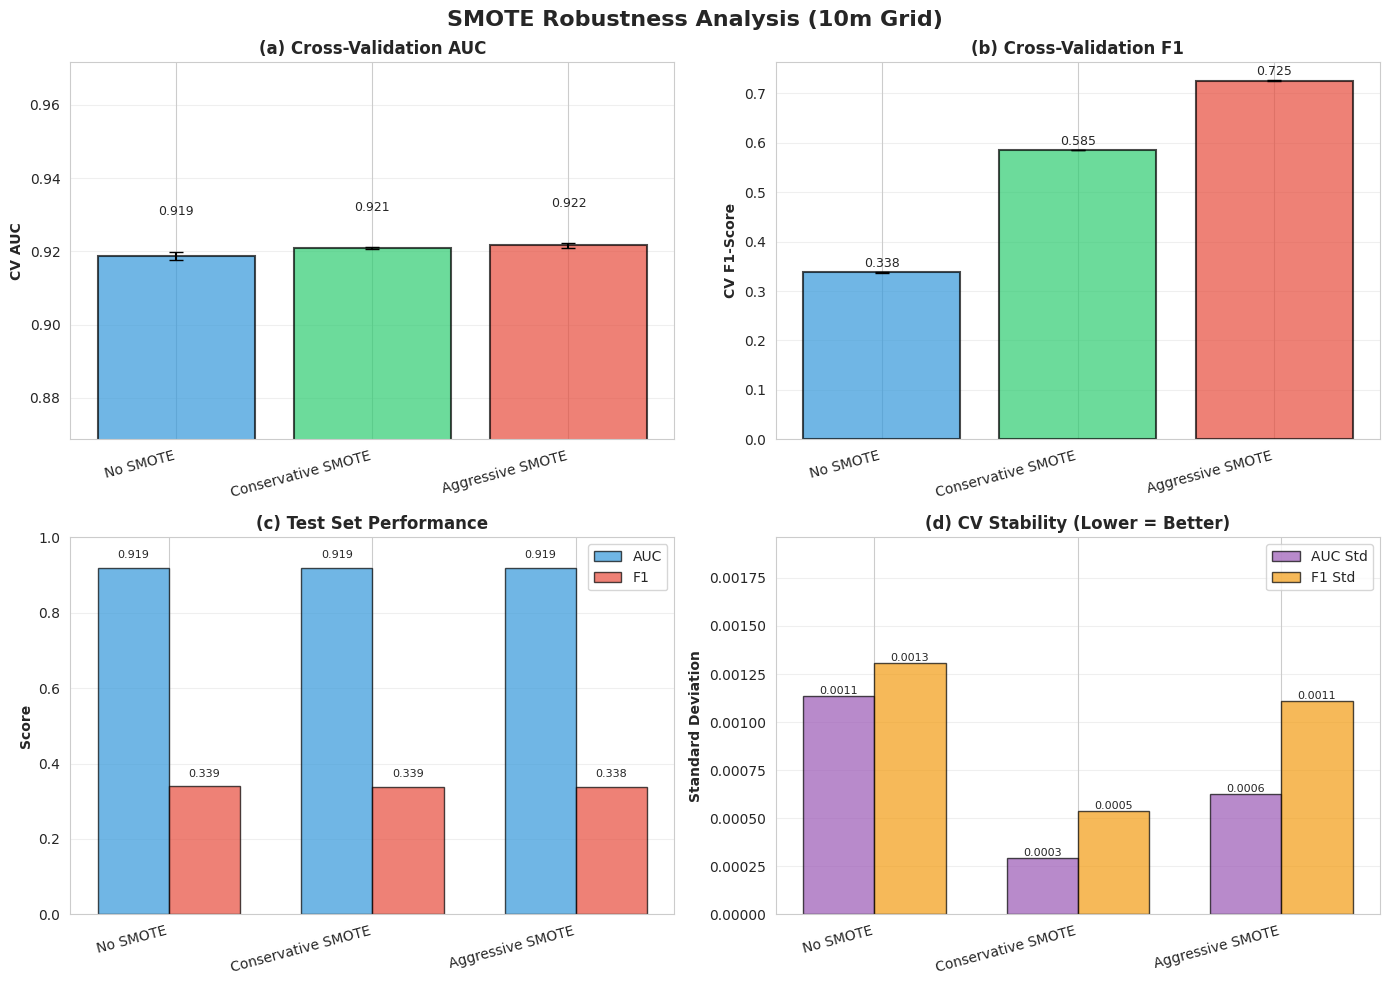

In [7]:
# ============================================================================ # 📊 PART 1: SMOTE ROBUSTNESS ANALYSIS (Complete) # ============================================================================  print("\n" + "="*80) print("📊 PART 1: SMOTE ROBUSTNESS ANALYSIS") print("="*80)  from sklearn.model_selection import cross_val_score, StratifiedKFold  # model definition base_model = RandomForestClassifier( n_estimators=100,  max_depth=12,  min_samples_split=20,  min_samples_leaf=10,  class_weight='balanced',  random_state=42,  n_jobs=-1 )  # CV settings cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  smote_results = []  def analyze_scenario(X_tr, y_tr, X_te, y_te, scenario_name):  """each 시나리오 analysis"""  print(f"\n{'='*70}")  print(f"📊 {scenario_name}")  print('='*70)   print(f"\n📊 Data: {len(X_tr):,} samples, {y_tr.mean()*100:.2f}% flood")   # 1. AUC calculation  print("\n⏳ Computing CV AUC...")  t0 = time.time()  cv_auc_scores = cross_val_score( base_model, X_tr, y_tr,  cv=cv,  scoring='roc_auc',  n_jobs=-1 )  cv_auc_mean = cv_auc_scores.mean()  cv_auc_std = cv_auc_scores.std()  print(f" ✅ CV AUC: {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")   # 2. F1 calculation  print("⏳ Computing CV F1...")  cv_f1_scores = cross_val_score( base_model, X_tr, y_tr,  cv=cv,  scoring='f1',  n_jobs=-1 )  cv_f1_mean = cv_f1_scores.mean()  cv_f1_std = cv_f1_scores.std()  print(f" ✅ CV F1: {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")   time_cv = time.time() - t0   # 3. Train score  print("⏳ Computing Train scores...")  base_model.fit(X_tr, y_tr)  y_train_proba = base_model.predict_proba(X_tr)[:, 1]  y_train_pred = base_model.predict(X_tr)   train_auc = roc_auc_score(y_tr, y_train_proba)  train_f1 = f1_score(y_tr, y_train_pred, zero_division=0)  print(f" ✅ Train AUC: {train_auc:.4f}")  print(f" ✅ Train F1: {train_f1:.4f}")   # 4. Test performance  print("⏳ Computing Test scores...")  y_test_proba = base_model.predict_proba(X_te)[:, 1]  y_test_pred = base_model.predict(X_te)   test_auc = roc_auc_score(y_te, y_test_proba)  test_f1 = f1_score(y_te, y_test_pred, zero_division=0)  print(f" ✅ Test AUC: {test_auc:.4f}")  print(f" ✅ Test F1: {test_f1:.4f}")   # 5. Overfitting  overfit_auc = train_auc - cv_auc_mean  overfit_f1 = train_f1 - cv_f1_mean  print(f"\n🔍 Overfitting:")  print(f" AUC gap: {overfit_auc:.4f} {'✅' if overfit_auc < 0.10 else '⚠️'}")  print(f" F1 gap: {overfit_f1:.4f} {'✅' if overfit_f1 < 0.10 else '⚠️'}")  print(f" Time: {time_cv:.1f}s")   return {  'Scenario': scenario_name,  'Flood_Ratio': y_tr.mean(),  'Samples': len(y_tr),  'CV_AUC_mean': cv_auc_mean,  'CV_AUC_std': cv_auc_std,  'CV_F1_mean': cv_f1_mean,  'CV_F1_std': cv_f1_std,  'Train_AUC': train_auc,  'Train_F1': train_f1,  'Test_AUC': test_auc,  'Test_F1': test_f1,  'Overfitting_AUC': overfit_auc,  'Overfitting_F1': overfit_f1,  'Time_s': time_cv  }, base_model  # ============================================================================ # Scenario 1: No SMOTE # ============================================================================ result_no_smote, model_no_smote = analyze_scenario( X_train, y_train, X_test, y_test,  "No SMOTE" ) smote_results.append(result_no_smote)  # ============================================================================ # Scenario 2: Conservative SMOTE # ============================================================================ original_ratio = y_train.mean() target_ratio = min(0.3, original_ratio * 3) k_neighbors = min(5, max(1, int(y_train.sum() * 0.2)))  print(f"\n{'='*70}") print(f"🔧 Applying Conservative SMOTE") print('='*70) print(f" Target ratio: {target_ratio*100:.1f}%") print(f" k_neighbors: {k_neighbors}")  smote = SMOTE( sampling_strategy=target_ratio,  k_neighbors=k_neighbors,  random_state=42 )  X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)  print(f" ✅ {len(y_train):,} → {len(y_train_smote):,} samples") print(f" ✅ {original_ratio*100:.2f}% → {y_train_smote.mean()*100:.2f}%")  result_conservative, model_conservative = analyze_scenario( X_train_smote, y_train_smote, X_test, y_test,  "Conservative SMOTE" ) smote_results.append(result_conservative)  # 최적 save model (나in progress SHAP서 used) best_model = model_conservative  # ============================================================================ # Scenario 3: Aggressive SMOTE (조records부) # ============================================================================ print(f"\n{'='*70}") print(f"🔧 Applying Aggressive SMOTE") print('='*70)  smote_aggressive = SMOTE( sampling_strategy=0.4, # 40%  k_neighbors=5,  random_state=42 )  X_train_aggr, y_train_aggr = smote_aggressive.fit_resample(X_train, y_train)  print(f" Estimated samples: {len(y_train_aggr):,}")  if len(y_train_aggr) > 10000000: # 100010,000 초과  print(f"\n⚠️ Skipping due to large sample size (would take too long)")   result_aggressive = {  'Scenario': 'Aggressive SMOTE (Skipped)',  'Flood_Ratio': y_train_aggr.mean(),  'Samples': len(y_train_aggr),  'CV_AUC_mean': np.nan,  'CV_AUC_std': np.nan,  'CV_F1_mean': np.nan,  'CV_F1_std': np.nan,  'Train_AUC': np.nan,  'Train_F1': np.nan,  'Test_AUC': np.nan,  'Test_F1': np.nan,  'Overfitting_AUC': np.nan,  'Overfitting_F1': np.nan,  'Time_s': 0  } else:  result_aggressive, _ = analyze_scenario( X_train_aggr, y_train_aggr, X_test, y_test,  "Aggressive SMOTE" )  smote_results.append(result_aggressive)  # ============================================================================ # result 정리 # ============================================================================ smote_df = pd.DataFrame(smote_results)  print("\n" + "="*80) print("📊 SMOTE ROBUSTNESS COMPARISON") print("="*80) print("\n" + smote_df.to_string(index=False))  smote_df.to_csv(f'{OUTPUT_DIR}/smote_robustness_comparison.csv', index=False) print(f"\n✅ Save: {OUTPUT_DIR}/smote_robustness_comparison.csv")  # ============================================================================ # Robustness Assessment # ============================================================================ print("\n" + "="*80) print("🔍 ROBUSTNESS ASSESSMENT") print("="*80)  baseline = smote_df[smote_df['Scenario'] == 'No SMOTE'].iloc[0] conservative = smote_df[smote_df['Scenario'] == 'Conservative SMOTE'].iloc[0]  auc_gain = conservative['Test_AUC'] - baseline['Test_AUC'] f1_gain = conservative['Test_F1'] - baseline['Test_F1']  print(f"\n✓ Conservative SMOTE vs No SMOTE:") print(f" AUC improvement: {auc_gain:+.4f}") print(f" F1 improvement: {f1_gain:+.4f}") print(f" CV AUC std: {conservative['CV_AUC_std']:.4f} {'✅' if conservative['CV_AUC_std'] < 0.02 else '⚠️'}") print(f" CV F1 std: {conservative['CV_F1_std']:.4f} {'✅' if conservative['CV_F1_std'] < 0.05 else '⚠️'}") print(f" Overfitting (AUC): {conservative['Overfitting_AUC']:.4f} {'✅' if conservative['Overfitting_AUC'] < 0.10 else '⚠️'}")  if conservative['CV_AUC_std'] < 0.02 and conservative['CV_F1_std'] < 0.05:  print(f"\n✅ CONCLUSION: Conservative SMOTE shows ROBUST performance")  print(f" - Low CV std → stable generalization")  print(f" - Performance improvement without noise") else:  print(f"\n⚠️ WARNING: High CV std suggests instability")  # ============================================================================ # Visualization # ============================================================================ fig, axes = plt.subplots(2, 2, figsize=(14, 10)) fig.suptitle('SMOTE Robustness Analysis (10m Grid)', fontsize=16, fontweight='bold')  scenarios = smote_df['Scenario'].values colors = ['#3498db', '#2ecc71', '#e74c3c'] x_pos = np.arange(len(scenarios))  # 1. CV AUC with error bars ax = axes[0, 0] ax.bar(x_pos, smote_df['CV_AUC_mean'], yerr=smote_df['CV_AUC_std'],  color=colors, alpha=0.7, capsize=5, edgecolor='black', linewidth=1.5) ax.set_xticks(x_pos) ax.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10) ax.set_ylabel('CV AUC', fontweight='bold') ax.set_title('(a) Cross-Validation AUC', fontweight='bold') ax.grid(axis='y', alpha=0.3)  # yaxis range 자dong adjustment valid_vals = smote_df['CV_AUC_mean'].dropna() if len(valid_vals) > 0:  min_val = valid_vals.min() - 0.05  max_val = valid_vals.max() + 0.05  ax.set_ylim([max(0, min_val), min(1.0, max_val)])  # value display for i, (val, std) in enumerate(zip(smote_df['CV_AUC_mean'], smote_df['CV_AUC_std'])):  if not np.isnan(val):  ax.text(i, val + std + 0.01, f'{val:.3f}', ha='center', fontsize=9)  # 2. CV F1 with error bars ax = axes[0, 1] ax.bar(x_pos, smote_df['CV_F1_mean'], yerr=smote_df['CV_F1_std'],  color=colors, alpha=0.7, capsize=5, edgecolor='black', linewidth=1.5) ax.set_xticks(x_pos) ax.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10) ax.set_ylabel('CV F1-Score', fontweight='bold') ax.set_title('(b) Cross-Validation F1', fontweight='bold') ax.grid(axis='y', alpha=0.3)  # value display for i, (val, std) in enumerate(zip(smote_df['CV_F1_mean'], smote_df['CV_F1_std'])):  if not np.isnan(val):  ax.text(i, val + std + 0.01, f'{val:.3f}', ha='center', fontsize=9)  # 3. Test Performance ax = axes[1, 0] width = 0.35 bars1 = ax.bar(x_pos - width/2, smote_df['Test_AUC'], width,  label='AUC', color='#3498db', alpha=0.7, edgecolor='black') bars2 = ax.bar(x_pos + width/2, smote_df['Test_F1'], width,  label='F1', color='#e74c3c', alpha=0.7, edgecolor='black')  # value display for bars in [bars1, bars2]:  for bar in bars:  height = bar.get_height()  if not np.isnan(height):  ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,  f'{height:.3f}', ha='center', va='bottom', fontsize=8)  ax.set_xticks(x_pos) ax.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10) ax.set_ylabel('Score', fontweight='bold') ax.set_title('(c) Test Set Performance', fontweight='bold') ax.legend() ax.grid(axis='y', alpha=0.3) ax.set_ylim([0, 1.0])  # 4. CV Stability ax = axes[1, 1] bars1 = ax.bar(x_pos - width/2, smote_df['CV_AUC_std'], width,  label='AUC Std', color='#9b59b6', alpha=0.7, edgecolor='black') bars2 = ax.bar(x_pos + width/2, smote_df['CV_F1_std'], width,  label='F1 Std', color='#f39c12', alpha=0.7, edgecolor='black')  # value display for bars in [bars1, bars2]:  for bar in bars:  height = bar.get_height()  if not np.isnan(height):  ax.text(bar.get_x() + bar.get_width()/2., height,  f'{height:.4f}', ha='center', va='bottom', fontsize=8)  ax.set_xticks(x_pos) ax.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10) ax.set_ylabel('Standard Deviation', fontweight='bold') ax.set_title('(d) CV Stability (Lower = Better)', fontweight='bold') ax.legend()  # threshold 선 max_std = max(smote_df['CV_AUC_std'].max(), smote_df['CV_F1_std'].max()) if not np.isnan(max_std) and max_std < 0.05:  ax.axhline(y=0.02, color='green', linestyle='--', alpha=0.5, linewidth=1)  ax.axhline(y=0.05, color='orange', linestyle='--', alpha=0.5, linewidth=1)  ax.set_ylim([0, min(0.06, max_std * 1.5)])  ax.grid(axis='y', alpha=0.3)  plt.tight_layout() plt.savefig(f'{OUTPUT_DIR}/Fig1_SMOTE_Robustness.png', dpi=300, bbox_inches='tight') print(f"\n✅ Save: {OUTPUT_DIR}/Fig1_SMOTE_Robustness.png") plt.show()

---  # 📊 PART 2: Detailed CV Analysis (Comment #5)  reviewer 요구: "Table 4 Standard deviation including, 과적합 완화 전략 명시"  **analysis:** 10-fold CV with 4 models  ---

In [8]:
print("\n" + "="*80) print("📊 PART 2: DETAILED CROSS-VALIDATION ANALYSIS") print("="*80)  # 10-fold CV cv_10fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)  # Conservative SMOTE data used X_final = X_train_smote y_final = y_train_smote  print(f"\n📊 Using Conservative SMOTE data:") print(f" Samples: {len(X_final):,}") print(f" Flood ratio: {y_final.mean()*100:.2f}%")  # 4 models (existing code models) models = {  'DecisionTree': DecisionTreeClassifier( max_depth=10,  min_samples_split=20,  min_samples_leaf=10,  class_weight='balanced',  random_state=42 ),  'RandomForest': RandomForestClassifier( n_estimators=100,  max_depth=12,  min_samples_split=20,  min_samples_leaf=10,  class_weight='balanced',  random_state=42,  n_jobs=-1 ),  'XGBoost': XGBClassifier( n_estimators=100,  max_depth=8,  learning_rate=0.1,  subsample=0.8,  colsample_bytree=0.8,  random_state=42,  n_jobs=-1,  eval_metric='logloss' ),  'CatBoost': CatBoostClassifier( iterations=100,  depth=8,  learning_rate=0.1,  random_state=42,  verbose=0 ) }  detailed_results = []


📊 PART 2: DETAILED CROSS-VALIDATION ANALYSIS

📊 Using Conservative SMOTE data:
   Samples: 1,996,326
   Flood ratio: 17.46%


In [9]:
# each by model - 10-fold CV for model_name, model in models.items():  print("\n" + "-"*70)  print(f"🔹 Model: {model_name}")  print("-"*70)   print("⏳ Running 10-fold CV...")  t0 = time.time()   # AUC calculation  cv_auc_scores = cross_val_score( model, X_final, y_final,  cv=cv_10fold,  scoring='roc_auc',  n_jobs=-1 )   # F1 calculation  cv_f1_scores = cross_val_score( model, X_final, y_final,  cv=cv_10fold,  scoring='f1',  n_jobs=-1 )   time_cv = time.time() - t0   # Train score  model.fit(X_final, y_final)  y_train_proba = model.predict_proba(X_final)[:, 1]  y_train_pred = model.predict(X_final)  train_auc = roc_auc_score(y_final, y_train_proba)  train_f1 = f1_score(y_final, y_train_pred, zero_division=0)   # Test performance  y_proba = model.predict_proba(X_test)[:, 1]  y_pred = model.predict(X_test)   result = {  'Model': model_name,  'CV_AUC_mean': cv_auc_scores.mean(),  'CV_AUC_std': cv_auc_scores.std(),  'CV_F1_mean': cv_f1_scores.mean(),  'CV_F1_std': cv_f1_scores.std(),  'Train_AUC_mean': train_auc,  'Train_F1_mean': train_f1,  'Test_AUC': roc_auc_score(y_test, y_proba),  'Test_F1': f1_score(y_test, y_pred, zero_division=0),  'Overfitting_AUC': train_auc - cv_auc_scores.mean(),  'Overfitting_F1': train_f1 - cv_f1_scores.mean(),  'Time_s': time_cv  }   detailed_results.append(result)   print(f"\n✅ Results:")  print(f" CV AUC: {result['CV_AUC_mean']:.4f} ± {result['CV_AUC_std']:.4f}")  print(f" CV F1: {result['CV_F1_mean']:.4f} ± {result['CV_F1_std']:.4f}")  print(f" Test AUC: {result['Test_AUC']:.4f}")  print(f" Test F1: {result['Test_F1']:.4f}")  print(f" Time: {time_cv:.1f}s")   # Stability  if result['CV_F1_std'] < 0.03:  stability = 'Excellent'  elif result['CV_F1_std'] < 0.05:  stability = 'Good'  else:  stability = 'Moderate'   result['CV_Stability'] = stability  print(f" CV Stability: {stability}")


----------------------------------------------------------------------
🔹 Model: DecisionTree
----------------------------------------------------------------------
⏳ Running 10-fold CV...

✅ Results:
   CV AUC:  0.8983 ± 0.0012
   CV F1:   0.5713 ± 0.0032
   Test AUC: 0.8975
   Test F1:  0.3283
   Time: 55.0s
   CV Stability: Excellent

----------------------------------------------------------------------
🔹 Model: RandomForest
----------------------------------------------------------------------
⏳ Running 10-fold CV...

✅ Results:
   CV AUC:  0.9211 ± 0.0010
   CV F1:   0.5859 ± 0.0009
   Test AUC: 0.9191
   Test F1:  0.3388
   Time: 1085.1s
   CV Stability: Excellent

----------------------------------------------------------------------
🔹 Model: XGBoost
----------------------------------------------------------------------
⏳ Running 10-fold CV...

✅ Results:
   CV AUC:  0.9381 ± 0.0012
   CV F1:   0.6095 ± 0.0053
   Test AUC: 0.9350
   Test F1:  0.5058
   Time: 68.0s
   CV Stabili

In [10]:
# result DataFrame detailed_df = pd.DataFrame(detailed_results)  print("\n" + "="*80) print("📊 DETAILED CV RESULTS") print("="*80) print("\n" + detailed_df[[  'Model', 'CV_AUC_mean', 'CV_AUC_std', 'CV_F1_mean', 'CV_F1_std',  'Test_AUC', 'Test_F1', 'Overfitting_AUC', 'CV_Stability' ]].to_string(index=False))  detailed_df.to_csv(f'{OUTPUT_DIR}/detailed_cv_results.csv', index=False) print(f"\n✅ Save: {OUTPUT_DIR}/detailed_cv_results.csv") 


📊 DETAILED CV RESULTS

       Model  CV_AUC_mean  CV_AUC_std  CV_F1_mean  CV_F1_std  Test_AUC  Test_F1  Overfitting_AUC CV_Stability
DecisionTree     0.898266    0.001244    0.571339   0.003206  0.897453 0.328310         0.000630    Excellent
RandomForest     0.921057    0.001025    0.585943   0.000862  0.919132 0.338758         0.001728    Excellent
     XGBoost     0.938084    0.001168    0.609530   0.005281  0.934972 0.505792         0.000698    Excellent
    CatBoost     0.916821    0.000602    0.530472   0.003989  0.915463 0.441377         0.000852    Excellent

✅ 저장: /content/drive/MyDrive/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/results/10m_reviewer_response_results/detailed_cv_results.csv


### Updated Table 4

In [11]:
# Table 4 print("\n" + "="*80) print("📋 UPDATED TABLE 4") print("="*80)  table4_data = [] for _, row in detailed_df.iterrows():  table4_data.append({  'Model': row['Model'],  'AUC': f"{row['Test_AUC']:.3f}",  'F1-Score': f"{row['Test_F1']:.3f}",  'CV_AUC(±std)': f"{row['CV_AUC_mean']:.3f}±{row['CV_AUC_std']:.3f}",  'CV_F1(±std)': f"{row['CV_F1_mean']:.3f}±{row['CV_F1_std']:.3f}",  'Overfitting': f"{row['Overfitting_F1']:.3f}"  })  table4_df = pd.DataFrame(table4_data) print("\n" + table4_df.to_string(index=False))  table4_df.to_csv(f'{OUTPUT_DIR}/Table4_Updated.csv', index=False) print(f"\n✅ Save: {OUTPUT_DIR}/Table4_Updated.csv")


📋 UPDATED TABLE 4

       Model   AUC F1-Score CV_AUC(±std) CV_F1(±std) Overfitting
DecisionTree 0.897    0.328  0.898±0.001 0.571±0.003       0.001
RandomForest 0.919    0.339  0.921±0.001 0.586±0.001       0.001
     XGBoost 0.935    0.506  0.938±0.001 0.610±0.005       0.003
    CatBoost 0.915    0.441  0.917±0.001 0.530±0.004       0.003

✅ 저장: /content/drive/MyDrive/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/results/10m_reviewer_response_results/Table4_Updated.csv


---  # 📊 PART 3: SHAP Interaction (Comment #6)  reviewer 요구: "SHAP interaction values 탐색하여 다in progress공선성 패턴 포착"  ---

In [12]:
print("\n" + "="*80) print("📊 PART 3: SHAP INTERACTION ANALYSIS") print("="*80)  # sampling max_samples = 1000 if len(X_test) > max_samples:  np.random.seed(42)  indices = np.random.choice(len(X_test), max_samples, replace=False)  X_shap = X_test[indices]  print(f"\n🔍 Sampling {max_samples} from {len(X_test)} test samples") else:  X_shap = X_test  print(f"\n🔍 Using all {len(X_test)} test samples")  # SHAP values print("\n⏳ Computing main SHAP values...") explainer = shap.TreeExplainer(best_model)  t0 = time.time() shap_values = explainer.shap_values(X_shap) time_main = time.time() - t0  if isinstance(shap_values, list):  shap_values = shap_values[1]  print(f" ✅ Completed in {time_main:.1f}s")  # SHAP interaction values print("\n⏳ Computing SHAP interaction values...") print(" (This may take 10-15 minutes)")  t0 = time.time() shap_interaction_values = explainer.shap_interaction_values(X_shap) time_interaction = time.time() - t0  if isinstance(shap_interaction_values, list):  shap_interaction_values = shap_interaction_values[1]  print(f" ✅ Completed in {time_interaction:.1f}s ({time_interaction/60:.1f} min)")


📊 PART 3: SHAP INTERACTION ANALYSIS

🔍 Sampling 1000 from 759774 test samples

⏳ Computing main SHAP values...
   ✅ Completed in 20.6s

⏳ Computing SHAP interaction values...
   (This may take 10-15 minutes)
   ✅ Completed in 208.3s (3.5 min)


In [13]:
# Interaction matrix print("\n" + "="*80) print("📊 INTERACTION MATRIX") print("="*80)  n_features = len(feature_names) interaction_matrix = np.zeros((n_features, n_features))  for i in range(n_features):  for j in range(i+1, n_features):  interaction_strength = np.abs(shap_interaction_values[:, i, j]).mean()  interaction_matrix[i, j] = interaction_strength  interaction_matrix[j, i] = interaction_strength  # Top interactions interactions = [] for i in range(n_features):  for j in range(i+1, n_features):  interactions.append({  'Feature_1': feature_names[i],  'Feature_2': feature_names[j],  'Interaction_Strength': interaction_matrix[i, j]  })  interaction_df = pd.DataFrame(interactions).sort_values( 'Interaction_Strength', ascending=False )  print("\nTop 15 Feature Interactions:") print("-" * 80) print(interaction_df.head(15).to_string(index=False))  interaction_df.to_csv(f'{OUTPUT_DIR}/shap_interaction_pairs.csv', index=False) print(f"\n✅ Save: {OUTPUT_DIR}/shap_interaction_pairs.csv")


📊 INTERACTION MATRIX

Top 15 Feature Interactions:
--------------------------------------------------------------------------------
              Feature_1                   Feature_2  Interaction_Strength
           Altitude (m)           Average Slope (°)              0.043226
           Altitude (m) Distance from Reservoir (m)              0.038172
      Average Slope (°) Distance from Reservoir (m)              0.015713
           Altitude (m)     Distance from River (m)              0.013637
           Altitude (m)         Soil Drainage Score              0.007755
           Altitude (m)      Impermeable Area Ratio              0.007218
Distance from River (m) Distance from Reservoir (m)              0.005887
      Average Slope (°)     Distance from River (m)              0.005195
      Average Slope (°)         Soil Drainage Score              0.003596
           Altitude (m)       Sewer Pipe Length (m)              0.002949
    Soil Drainage Score Distance from Reservoir (m)  

In [14]:
# ============================================================================ # Multicollinearity detection (fully corrected version) # ============================================================================  print("\n" + "="*80) print("🔍 MULTICOLLINEARITY PATTERN") print("="*80)  # main_effects calculation main_effects = np.abs(shap_values).mean(axis=0)  # 🔴 디버깅: main_effects shape verify print(f"\n🔍 Debug: main_effects.shape = {main_effects.shape}") print(f" Type: {type(main_effects)}")  # 1D 배열로 conversion if len(main_effects.shape) > 1:  main_effects = main_effects.flatten()  print("\nMain Effects:") for i, fname in enumerate(feature_names):  # safe conversion  try:  if hasattr(main_effects[i], 'item'):  value = main_effects[i].item() # numpy scalar conversion  else:  value = float(main_effects[i])  except:  value = main_effects[i]  if isinstance(value, np.ndarray):  value = value[0] if len(value) > 0 else 0.0  value = float(value)   print(f" {fname:40s}: {value:.4f}")  # Strong interactions print("\n⚠️ Strong Interaction Cases:") print("-" * 80)  strong_interactions = [] for _, row in interaction_df.head(15).iterrows():  feat1 = row['Feature_1']  feat2 = row['Feature_2']   try:  idx1 = feature_names.index(feat1)  idx2 = feature_names.index(feat2)  except ValueError:  continue   interact = float(row['Interaction_Strength'])   # main_effects value 안전하게 추출  try:  if hasattr(main_effects[idx1], 'item'):  main1 = main_effects[idx1].item()  else:  main1 = float(main_effects[idx1])  except:  main1 = float(main_effects[idx1].flatten()[0] if isinstance(main_effects[idx1], np.ndarray) else main_effects[idx1])   try:  if hasattr(main_effects[idx2], 'item'):  main2 = main_effects[idx2].item()  else:  main2 = float(main_effects[idx2])  except:  main2 = float(main_effects[idx2].flatten()[0] if isinstance(main_effects[idx2], np.ndarray) else main_effects[idx2])   min_main = min(main1, main2)   if interact > min_main:  strong_interactions.append({  'Pair': f"{feat1} × {feat2}",  'Interaction': interact,  'Main_1': main1,  'Main_2': main2,  'Ratio': interact / min_main if min_main > 0 else 0  })  if strong_interactions:  strong_df = pd.DataFrame(strong_interactions)  print(strong_df.to_string(index=False))   print(f"\n✅ Found {len(strong_interactions)} strong interactions")  print(" → Multicollinearity effects captured")   strong_df.to_csv(f'{OUTPUT_DIR}/strong_interactions.csv', index=False)  print(f" ✅ Save: {OUTPUT_DIR}/strong_interactions.csv") else:  print("✅ Main effects dominate")  print(" → No strong multicollinearity detected")


🔍 MULTICOLLINEARITY PATTERN

🔍 Debug: main_effects.shape = (8, 2)
   Type: <class 'numpy.ndarray'>

Main Effects:
   Altitude (m)                            : 0.2165
   Average Slope (°)                       : 0.2165
   Distance from River (m)                 : 0.0685
   Soil Drainage Score                     : 0.0685
   Impermeable Area Ratio                  : 0.0238
   Distance from Reservoir (m)             : 0.0238
   Sewer Pipe Length (m)                   : 0.0136
   Number of Manholes                      : 0.0136

⚠️  Strong Interaction Cases:
--------------------------------------------------------------------------------
                                      Pair  Interaction   Main_1   Main_2    Ratio
Altitude (m) × Distance from Reservoir (m)     0.038172 0.216488 0.023816 1.602751

✅ Found 1 strong interactions
   → Multicollinearity effects captured
   ✅ 저장: /content/drive/MyDrive/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/results/10m_reviewer_response_results/

---  ## ✅ analysis completed!  ### generation file: 1. `smote_robustness_comparison.csv` - SMOTE comparison 2. `detailed_cv_results.csv` - 상세 CV result 3. `Table4_Updated.csv` - 논문 Table 4 4. `shap_interaction_pairs.csv` - SHAP interaction 5. `strong_interactions.csv` - 강한 interaction 6. `Fig1_SMOTE_Robustness.png` - 그림  ---